In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import functools
import gc
import os
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
from math import pi
import random

import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize
import tqdm.contrib.itertools
import xarray as xr

from fluxoniumcr import DATA_DIR
from fluxoniumcr.plotting.cookbook import imshow_heatmap
from fluxoniumcr.qubits.fluxonium import Fluxonium
from fluxoniumcr.spectrum.autodiff import FunctionSum
from fluxoniumcr.spectrum.esd_oracle import ESDOracle
from fluxoniumcr.utils import load_arguments

In [3]:
RAMP_DURATION = 50.0
RAMP_SHAPE = 'planck'

In [4]:
EJ_0 = 4.0 * (2*pi)
EC_0 = 1.2 * (2*pi)
EL_0 = 0.4 * (2*pi)
deltap = 0.8

parent_path = (
    DATA_DIR
    /"control_target_collision"
    / f"EJ={EJ_0/(2*pi):.2f},EC={EC_0/(2*pi):.2f},EL={EL_0/(2*pi):.2f},deltap={deltap}"
)
parent_path.mkdir(parents=True, exist_ok=True)

q0 = Fluxonium(
    EJ=EJ_0,
    EC=EC_0,
    EL=EL_0,
    dim=16,
    cutoff=128,
)
q0_evals = q0.eigenvalues

esd_dataset = xr.load_dataset(
    DATA_DIR/"charge_operator"
    / f"EJ={EJ_0/(2*pi):.2f},EC={EC_0/(2*pi):.2f},EL={EL_0/(2*pi):.2f}"
    / f"esd.hdf5"
).sel(deltap=deltap, method='nearest')

esd_oracle = ESDOracle(esd_dataset)

assert esd_dataset.attrs['ramp_shape'] == RAMP_SHAPE
assert esd_dataset.attrs['ramp_duration'] == RAMP_DURATION

gc.collect()

60

# Compute Target fluxonium 1-2 resonance parameters

In [144]:
EC_coord = xr.DataArray(
    np.linspace(1.0, 1.5, 51) * 2*pi,
    dims=['EC'],
)
EL_coord = xr.DataArray(
    np.linspace(0.1, 2.0, 191) * 2*pi,
    dims=['EL'],
)
index_coord = xr.DataArray(
    np.arange(6),
    dims=['index']
)

resonance_dataset = xr.Dataset(
    attrs=dict(
        EJ_0=EJ_0,
        EC_0=EC_0,
        EL_0=EL_0,
        deltap=deltap,
    )
)

resonance_dataset['EJ'] = xr.DataArray(
    np.nan,
    coords=[index_coord, EC_coord, EL_coord],
)
resonance_dataset['harmonic'] = xr.DataArray(
    [-2, -2, -3, -4, -4, -4],
    coords=[index_coord],
)
resonance_dataset['target_final_state'] = xr.DataArray(
    [2, 2, 2, 2, 2, 3],
    coords=[index_coord],
)
resonance_dataset['target_initial_state'] = xr.DataArray(
    [1, 1, 1, 1, 1, 0],
    coords=[index_coord],
)
resonance_dataset['control_final_state'] = xr.DataArray(
    [1, 0, 0, 1, 0, 0],
    coords=[index_coord],
)
resonance_dataset['control_initial_state'] = xr.DataArray(
    [0, 1, 0, 0, 1, 1],
    coords=[index_coord],
)

In [145]:
def fobj(
        EJ,
        EC,
        EL,
        target_initial_state,
        target_final_state,
        control_initial_state,
        control_final_state,
        harmonic,
        sideband_frequency=None,
):
    fx = Fluxonium(
        EJ=EJ,
        EC=EC,
        EL=EL,
        dim=4,
        cutoff=128,
    )
    evals = fx.eigenvalues
    w10 = evals[..., 1] - evals[..., 0]
    wbad = (
        evals[..., target_final_state]
        - evals[..., target_initial_state]
    )
    
    if sideband_frequency is None:
        if control_final_state == control_initial_state:
            pole = harmonic*w10
        else:
            # XXX: esd_dataset harmonics are calculated with glide reflection symmetry
            # so all harmonics are odd.
            if control_initial_state == 0 and control_final_state == 1:
                assert harmonic % 2 == 0
                modified_harmonic = harmonic + 1
            elif control_initial_state == 1 and control_final_state == 0:
                assert harmonic % 2 == 0
                modified_harmonic = harmonic - 1
            spec = esd_oracle.interpolate(w10).get_matrix_element(
                harmonic=modified_harmonic,
                bra=control_final_state,
                ket=control_initial_state,
            )
            pole = spec.pole
        return wbad + pole
    else:
        return wbad + harmonic*w10 + sideband_frequency

In [146]:
for index, EC, EL in tqdm.contrib.itertools.product(
        resonance_dataset.index.data,
        resonance_dataset.EC.data,
        resonance_dataset.EL.data,
):
    ds = resonance_dataset.loc[dict(
        index=index,
        EC=EC,
        EL=EL,
    )]
    harmonic = ds.harmonic.item()
    target_initial_state = ds.target_initial_state.item()
    target_final_state = ds.target_final_state.item()
    control_initial_state = ds.control_initial_state.item()
    control_final_state = ds.control_final_state.item()

    fobj_kwargs = dict(
        EC=EC,
        EL=EL,
        target_initial_state=target_initial_state,
        target_final_state=target_final_state,
        control_initial_state=control_initial_state,
        control_final_state=control_final_state,
        harmonic=harmonic,
    )
    
    if control_final_state == control_initial_state:
        try:
            EJ = scipy.optimize.brentq(
                lambda x: fobj(x, **fobj_kwargs),
                # XXX: Hardcoded bounds
                0.1 * 2*pi,
                10 * 2*pi,
            )
        except ValueError:
            continue
    else:
        try:
            # Find a rough EJ assuming the control qubit transitions are not ac Stark shifted.
            EJ_guess = scipy.optimize.brentq(
                lambda x: fobj(
                    x,
                    **fobj_kwargs,
                    sideband_frequency=(
                        q0_evals[control_final_state]
                        - q0_evals[control_initial_state]
                    ),
                ),
                # XXX: Hardcoded bounds
                0.1 * 2*pi,
                10 * 2*pi,
            )
            EJ = scipy.optimize.brentq(
                lambda x: fobj(x, **fobj_kwargs),
                EJ_guess*0.9,
                EJ_guess*1.1,
            )
        except ValueError:
            continue
            
    ds.EJ[()] = EJ

  0%|          | 0/58446 [00:00<?, ?it/s]

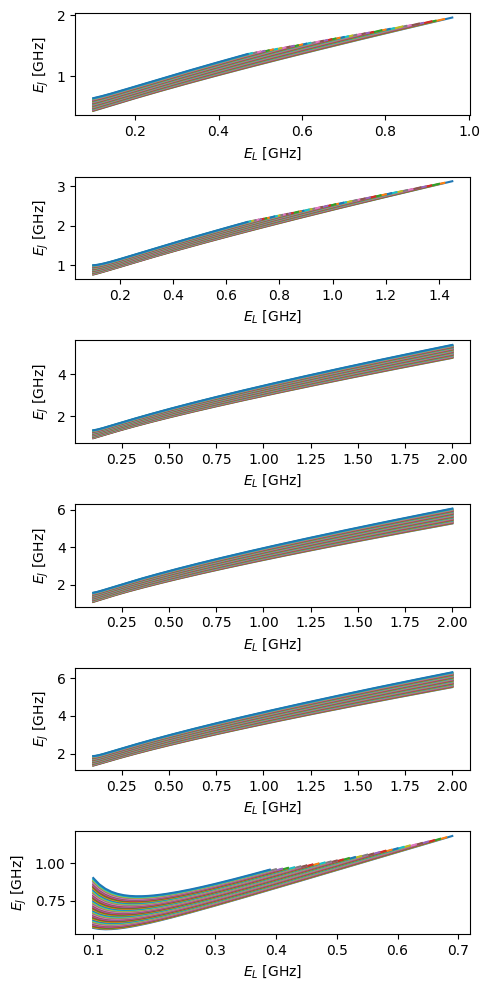

In [147]:
fig, axs = plt.subplots(nrows=6, figsize=(5, 10))

for index, ax in zip(resonance_dataset.index.data, axs):
    for EC in resonance_dataset.EC.data:
        ds = resonance_dataset.sel(index=index, EC=EC)
        ax.plot(ds.EL/(2*pi), ds.EJ/(2*pi))
    ax.set_xlabel("$E_L$ [GHz]")
    ax.set_ylabel("$E_J$ [GHz]")

fig.tight_layout()

In [ ]:
# Save the parameters with resonances so we can load it at a later date.
# resonance_dataset.to_netcdf(parent_path/"resonance_parameters.hdf5")

In [5]:
# Load the parameters with unwanted resonances.
resonance_dataset = xr.load_dataset(parent_path/"resonance_parameters.hdf5")

# Calculate leakage probability

In [6]:
from scipy.stats import qmc


def generate_random_parameters(
        resonance_index,
        delta_EJ,
        size,
):
    sampler = qmc.Sobol(d=2, scramble=True)
    # XXX: Over sample since we will mask some points later.
    u, v = sampler.random_base2(int(np.ceil(np.log2(size))+4)).T

    EC_array = xr.DataArray(
        np.min(resonance_dataset.EC.data) + u * np.ptp(resonance_dataset.EC.data),
        dims=['dim_0'],
    )
    EL_array = xr.DataArray(
        np.min(resonance_dataset.EL.data) + v * np.ptp(resonance_dataset.EL.data),
        dims=['dim_0'],
    )
    
    EJ_array = resonance_dataset.EJ.sel(
        index=resonance_index
    ).interp(EC=EC_array, EL=EL_array)
    EJ_array += delta_EJ * np.random.uniform(-1, +1, len(EJ_array))
    
    ELdivEJ_array = EL_array/EJ_array
    
    mask = (
        (EJ_array >= 2 * (2*pi))
        & (EJ_array <= 10 * (2*pi))
        & (ELdivEJ_array >= 0.1)
        & (ELdivEJ_array <= 0.5)
    )
    
    EJ_array = EJ_array[mask][:size]
    EC_array = EC_array[mask][:size]
    EL_array = EL_array[mask][:size]
    
    # XXX: This is not guaranteed if we did not oversample enough.
    assert len(EJ_array) == size, len(EJ_array)
    
    return EJ_array.data, EC_array.data, EL_array.data

In [7]:
def create_dataset(
        resonance_index,
        delta_EJ,
        JC_values,
        num_points,
        bin_edges=None,
):
    rds = resonance_dataset.sel(index=resonance_index)
    harmonic = rds.harmonic.item()
    control_initial_state = rds.control_initial_state.item()
    control_final_state = rds.control_final_state.item()
    target_initial_state = rds.target_initial_state.item()
    target_final_state = rds.target_final_state.item()
    
    dataset = xr.Dataset(attrs=dict(
        control_initial_state=control_initial_state,
        control_final_state=control_final_state,
        target_initial_state=target_initial_state,
        target_final_state=target_final_state,
        harmonic=harmonic,
        ramp_duration=RAMP_DURATION,
        ramp_shape=RAMP_SHAPE,
    ))

    JC_coord = xr.DataArray(
        JC_values,
        dims=['JC'],
    )
    index_coord = xr.DataArray(
        np.arange(num_points),
        dims=['index'],
    )
    control_bra_coord = xr.DataArray(
        np.arange(8),
        dims=['control_bra'],
    )
    target_bra_coord = xr.DataArray(
        np.arange(4),
        dims=['target_bra'],
    )
    control_ket_coord = xr.DataArray(
        np.arange(2),
        dims=['control_ket'],
    )
    target_ket_coord = xr.DataArray(
        np.arange(2),
        dims=['target_ket'],
    )
    dataset['transition_probability'] = xr.DataArray(
        np.nan,
        coords=[
            JC_coord,
            index_coord,
            control_bra_coord,
            target_bra_coord,
            control_ket_coord,
            target_ket_coord,
        ]
    )
    dataset['model_error'] = xr.DataArray(
        np.nan,
        coords=[JC_coord, index_coord],
        attrs=dict(
            long_name="Model error contribution"
        )
    )

    keep_params = {}
    done = False
    
    for _ in range(100):
        if done: break
            
        EJ_values, EC_values, EL_values = generate_random_parameters(
            resonance_index,
            delta_EJ,
            num_points,
        )
        
        if bin_edges is None:
            break

        fx = Fluxonium(
            EJ=EJ_values,
            EC=EC_values,
            EL=EL_values,
            flux=0.5,
            dim=3,
            # Determining which targets are close to resonance doesn't need to be very accurate.
            cutoff=32,
        )
        fx_evals = fx.eigenvalues
        indices = np.digitize(
            fx_evals[..., 1] - fx_evals[..., 0],
            bin_edges,
        )
        for i in range(1, len(bin_edges)):
            params_list = keep_params.setdefault(i, [])
            mask = indices == i
            extra = list(zip(
                EJ_values[mask],
                EC_values[mask],
                EL_values[mask],
            ))
            params_list.extend(extra)
        
        threshold = round(np.ceil(num_points/(len(bin_edges) - 1)))
        for i in range(1, len(bin_edges)):
            if i not in keep_params:
                break
            params_list = keep_params[i]
            if len(params_list) < threshold:
                # Log progress.
                print(i, bin_edges[i-1]/(2*pi), f"{len(params_list)}/{threshold}")
                break
        else:
            done = True
    else:
        raise RuntimeError("Sampling failed.")
    
    if len(keep_params) > 0:
        keep_params_list = []
        for plist in keep_params.values():
            keep_params_list.extend(plist[:int(np.ceil(num_points/(len(bin_edges) - 1)))])
        random.shuffle(keep_params_list)
        keep_params_list = keep_params_list[:num_points]
        EJ_values, EC_values, EL_values = map(list, zip(*keep_params_list))
    
    dataset['EJ'] = xr.DataArray(
        EJ_values,
        coords=[index_coord],
        attrs=dict(
            unit="Grad/s"
        )   
    )
    dataset['EC'] = xr.DataArray(
        EC_values,
        coords=[index_coord],
        attrs=dict(
            unit="Grad/s"
        )   
    )
    dataset['EL'] = xr.DataArray(
        EL_values,
        coords=[index_coord],
        attrs=dict(
            unit="Grad/s"
        )   
    )
    dataset['drive_frequency'] = xr.DataArray(
        np.nan,
        coords=[index_coord],
        attrs=dict(
            long_name="Target qubit 0 to 1 bare frequency",
            unit="Grad/s",
        )
    )
    dataset['transition_frequency'] = xr.DataArray(
        np.nan,
        coords=[index_coord],
        attrs=dict(
            long_name="Target qubit bare transition frequency",
            unit="Grad/s",
        )
    )
    dataset['delta_frequency'] = xr.DataArray(
        np.nan,
        coords=[index_coord],
        attrs=dict(
            long_name="Detuning from dressed resonance",
            unit="Grad/s",
        )
    )
    dataset['drive_amplitude'] = xr.DataArray(
        np.nan,
        coords=[index_coord],
        attrs=dict(
            long_name="Drive amplitude",
            unit="Grad/s",
        )
    )
    
    return dataset

In [8]:
from multiprocessing.pool import Pool

from fluxoniumcr.qubits.product_basis import DressedProductBasis
from fluxoniumcr.simulation.root import create_two_coupled_qubits
from fluxoniumcr.simulation.module import (
    OperatorResolver,
)
from fluxoniumcr.simulation.cnot_solver import (
    CNOTSolver,
)
from fluxoniumcr.simulation.cnot_solver import (
    CNOTParameters,
    SmoothSquareParameters,
)
from fluxoniumcr.simulation.signals import planck_taper_signal, cosine_taper_signal


def doit(
        q1_params,
        JC,
        control_initial_state,
        control_final_state,
        target_initial_state,
        target_final_state,
        harmonic,
):
    EJ_1, EC_1, EL_1 = q1_params
    
    q1 = Fluxonium(
        EJ=EJ_1,
        EC=EC_1,
        EL=EL_1,
        dim=16,
        cutoff=128,
    )
    q1_evals = q1.eigenvalues
    n1_op = q1.get_operator('charge')
    
    freq10 = q1_evals[1] - q1_evals[0]
    transition_freq = (
        q1_evals[target_final_state]
        - q1_evals[target_initial_state]
    )
    
    amplitude = esd_oracle.interpolate(freq10).drive_amplitude
    
    if control_final_state == control_initial_state:
        spec0 = esd_oracle.interpolate(freq10).get_matrix_element(
            harmonic=harmonic,
            bra=0,
            ket=0,
        )
        spec1 = esd_oracle.interpolate(freq10).get_matrix_element(
            harmonic=harmonic,
            bra=1,
            ket=1,
        )
        spec = FunctionSum([spec0, spec1])
        delta = transition_freq + harmonic*freq10
    else:
        # XXX: esd_dataset harmonics are calculated with glide reflection symmetry
        # so all harmonics are odd.
        if control_initial_state == 0 and control_final_state == 1:
            assert harmonic % 2 == 0
            modified_harmonic = harmonic + 1
        elif control_initial_state == 1 and control_final_state == 0:
            assert harmonic % 2 == 0
            modified_harmonic = harmonic - 1
        spec = esd_oracle.interpolate(freq10).get_matrix_element(
            harmonic=modified_harmonic,
            bra=control_final_state,
            ket=control_initial_state,
        )
        delta = transition_freq + spec.pole
        
    model_error = (
        0.25 * JC**2 *
        abs(n1_op[target_final_state, target_initial_state])**2
        * spec(-transition_freq)
    )

    if RAMP_SHAPE == 'planck':
        pulse_factory = planck_taper_signal
    elif RAMP_SHAPE == 'cosine':
        pulse_factory = cosine_taper_signal
    else:
        raise ValueError(RAMP_SHAPE)
    
    gate_parameters = CNOTParameters(
        pulse_parameters=SmoothSquareParameters(
            total_duration=0.0,
            ramp_duration=RAMP_DURATION,
            amplitude=amplitude,
            carrier_freq=freq10,
        ),
        pulse_factory=pulse_factory,
    )
    
    truncated_dims = (8, 4)
    root = create_two_coupled_qubits(
        q0,
        q1,
        JC,
        truncated_dims=truncated_dims,
    )
    basis = root.get(DressedProductBasis)
    cnot_solver = root.get(CNOTSolver)
    
    probs = cnot_solver.calculate_transition_probabilities(gate_parameters)
    
    transition_probability = probs[np.ix_(
        [
            basis.flat_index((i, j))
            for i in range(truncated_dims[0])
            for j in range(truncated_dims[1])
        ],
        [
            basis.flat_index((i, j))
            for i in range(2)
            for j in range(2)
        ],
    )]
    transition_probability = transition_probability.reshape(
        *truncated_dims, 2, 2,
    )
    
    return (
        freq10,
        transition_freq,
        delta,
        amplitude,
        transition_probability,
        model_error,
    )


def populate_dataset(dataset, num_processes=10):
    with Pool(processes=num_processes) as pool:
        for JC in dataset.JC.data:
            print(f"{JC/(2*pi)=!s}")
            ds_outer = dataset.loc[dict(JC=JC)]
            for index, return_values in tqdm.contrib.tzip(
                    dataset.index.data,
                    pool.imap(
                        functools.partial(
                            doit,
                            JC=JC,
                            harmonic=dataset.attrs['harmonic'],
                            control_initial_state=dataset.attrs['control_initial_state'],
                            control_final_state=dataset.attrs['control_final_state'],
                            target_initial_state=dataset.attrs['target_initial_state'],
                            target_final_state=dataset.attrs['target_final_state'],
                        ),
                        zip(
                            dataset.EJ.data,
                            dataset.EC.data,
                            dataset.EL.data,
                        )
                    ),
            ):
                (
                        freq10,
                        transition_freq,
                        delta,
                        amplitude,
                        transition_probability,
                        model_error,
                ) = return_values

                ds = ds_outer.loc[dict(index=index)]
                ds.drive_frequency[()] = freq10
                ds.transition_frequency[()] = transition_freq
                ds.delta_frequency[()] = delta
                ds.drive_amplitude[()] = amplitude
                ds.transition_probability[()] = transition_probability
                ds.model_error[()] = model_error

# Create dataset

In [156]:
dataset = create_dataset(
    resonance_index=2,
    delta_EJ=0.3,
    JC_values=[10e-3 * (2*pi), 100e-3 * (2*pi)],
    num_points=2**16,
    bin_edges=np.linspace(0.85, 1.55, 71) * (2*pi),
)

1 0.85 211/937
1 0.85 438/937
1 0.85 644/937
1 0.85 845/937


In [133]:
dataset = create_dataset(
    resonance_index=3,
    delta_EJ=0.3,
    JC_values=[100e-3 * (2*pi)],
    num_points=2**16,
    bin_edges=np.linspace(0.7, 1.31, 62) * (2*pi),
)

1 0.7 427/1075
1 0.7 815/1075
57 1.26 831/1075
57 1.26 1064/1075
59 1.28 724/1075
59 1.28 867/1075
59 1.28 1007/1075
60 1.29 720/1075
60 1.29 802/1075
60 1.29 892/1075
60 1.29 982/1075
61 1.3 489/1075
61 1.3 525/1075
61 1.3 572/1075
61 1.3 619/1075
61 1.3 671/1075
61 1.3 704/1075
61 1.3 747/1075
61 1.3 792/1075
61 1.3 836/1075
61 1.3 879/1075
61 1.3 924/1075
61 1.3 973/1075
61 1.3 1009/1075
61 1.3 1046/1075


In [139]:
dataset = create_dataset(
    resonance_index=4,
    delta_EJ=0.3,
    JC_values=[100e-3 * (2*pi)],
    num_points=2**16,
    bin_edges=np.linspace(0.6, 1.21, 62) * (2*pi),
)

1 0.6 448/1075
1 0.6 911/1075
58 1.17 957/1075
60 1.19 768/1075
60 1.19 954/1075
61 1.2 823/1075
61 1.2 947/1075
61 1.2 1070/1075


In [41]:
dataset = create_dataset(
    resonance_index=1,
    delta_EJ=0.4,
    JC_values=[100e-3 * (2*pi)],
    num_points=2**16,
    bin_edges=np.linspace(1.15, 1.51, 37) * (2*pi),
)

1 1.15 161/1821
1 1.15 323/1821
1 1.15 482/1821
1 1.15 638/1821
1 1.15 787/1821
1 1.15 930/1821
1 1.15 1074/1821
1 1.15 1232/1821
1 1.15 1377/1821
1 1.15 1537/1821
1 1.15 1699/1821


# Run and save

In [ ]:
populate_dataset(dataset)

In [45]:
file_name = (
    f"{dataset.control_initial_state}"
    f"{dataset.target_initial_state}"
    "to"
    f"{dataset.control_final_state}"
    f"{dataset.target_final_state}"
    "_harmonic="
    f"{dataset.harmonic}"
    ".hdf5"
)

dataset.to_netcdf(parent_path/file_name)

print(file_name)

11to02_harmonic=-2.hdf5
